# 01 – Datenexploration des NK/CMV-Datensatzes

Dieses Notebook verschafft einen reproduzierbaren ersten Überblick über Dateien, Labels, Marker und Messwerte. Es führt bewusst **noch keine** PCA-, t-SNE-, UMAP- oder Clusteranalyse durch; diese Schritte gehören in die folgenden Notebooks.

Zentrale Regeln für alle späteren Analysen:

- Ein FCS-Event entspricht einer Zelle, aber die unabhängige Beobachtungseinheit ist der **Spender**.
- Training/Test-Splits dürfen daher nie auf Zellebene erfolgen.
- Bei gemeinsamen Darstellungen werden gleich viele Zellen je Spender gezogen, damit große Samples das Bild nicht dominieren.
- Die Originaldateien werden nur gelesen und nicht verändert.

In [1]:
from pathlib import Path
import importlib.metadata as package_metadata
import warnings

import flowkit as fk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")

# Paketversionen helfen dabei, Ergebnisse später exakt nachzuvollziehen.
pd.Series({
    name: package_metadata.version(name)
    for name in ["flowkit", "numpy", "pandas", "matplotlib", "seaborn"]
}, name="version")

flowkit        1.3.2
numpy          2.5.2
pandas         2.3.3
matplotlib    3.11.1
seaborn       0.13.2
Name: version, dtype: object

## 1. Projektpfade

Die Pfadsuche funktioniert sowohl beim Start von JupyterLab im Projektstamm als auch beim Ausführen aus dem Ordner `notebooks`. Dadurch enthält das Notebook keine rechnerabhängigen absoluten Pfade.

In [2]:
def find_project_root(start: Path) -> Path:
    """Finde den Projektstamm anhand der erwarteten Originaldateien."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "NK_cell_dataset").exists():
            return candidate
    raise FileNotFoundError("Projektstamm konnte nicht gefunden werden.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "NK_cell_dataset" / "NK_cell_dataset"
FCS_ROOT = DATA_ROOT / "NK_cell_dataset"
ALIVE_DIR = FCS_ROOT / "gated_alive"
NK_DIR = FCS_ROOT / "gated_NK"
LABELS_PATH = DATA_ROOT / "NK_fcs_samples_with_labels.csv"
MARKERS_PATH = DATA_ROOT / "NK_markers.csv"
SAMPLE_OVERVIEW_PATH = PROJECT_ROOT / "untersuchung" / "sample_overview.csv"

assert all(path.exists() for path in [ALIVE_DIR, NK_DIR, LABELS_PATH, MARKERS_PATH])
PROJECT_ROOT

WindowsPath('C:/Users/marie/Documents/System Teamproject/SSBI-Project')

## 2. Labels, Marker und Dateiinventar

Die Labeldatei referenziert die NK-gegateten FCS-Dateien. Laut offiziellem CellCNN-Beispiel bedeutet `0 = CMV−` und `1 = CMV+`. Die Markerdatei enthält genau die biologischen Kanäle, die für die Modellierung vorgesehen sind.

In [3]:
labels = pd.read_csv(LABELS_PATH)
labels["clinical_group"] = labels["label"].map({0: "CMV−", 1: "CMV+"})
labels["sample_id"] = labels["fcs_filename"].str.replace("_NK.fcs", "", regex=False)

# NK_markers.csv besteht aus einer einzigen Zeile ohne Spaltenkopf.
markers = pd.read_csv(MARKERS_PATH, header=None).iloc[0].dropna().tolist()

assert labels["fcs_filename"].is_unique
assert set(labels["label"]) == {0, 1}
assert len(markers) == 37 and len(set(markers)) == 37

display(labels)
print(f"Anzahl Analysemarker: {len(markers)}")
print(", ".join(markers))

,fcs_filename,label,clinical_group,sample_id
0,a_001_NK.fcs,1,CMV+,a_001
1,a_002_NK.fcs,1,CMV+,a_002
2,a_003_NK.fcs,0,CMV−,a_003
3,a_004_NK.fcs,0,CMV−,a_004
4,a_005_NK.fcs,1,CMV+,a_005
5,a_006_NK.fcs,0,CMV−,a_006
6,a_007_NK.fcs,1,CMV+,a_007
7,a_009_NK.fcs,0,CMV−,a_009
8,a_010_NK.fcs,0,CMV−,a_010
9,a_011_NK.fcs,0,CMV−,a_011


Anzahl Analysemarker: 37
CD3, CD27, CD19, CD4, CD8, CD57, 2DL1-S1, TRAIL, 2DL2-L3-S2, CD16, CD10, 3DL1-S1, CD117, 2DS4, ILT2-CD85j, NKp46, NKG2D, NKG2C, 2B4, CD33, CD11b, NKp30, CD122, 3DL1, NKp44, CD127, 2DL1, CD94, CD34, CCR7, 2DL3, NKG2A, HLA-DR, 2DL4, CD56, 2DL5, CD25


In [4]:
alive_files = sorted(ALIVE_DIR.glob("*.fcs"))
nk_files = sorted(NK_DIR.glob("*.fcs"))
apple_sidecars = sorted((PROJECT_ROOT / "NK_cell_dataset" / "__MACOSX").rglob("._*.fcs"))

# Nur die großen Dateien in gated_alive/gated_NK sind Messdaten.
inventory = pd.DataFrame({
    "category": ["gated_alive", "gated_NK", "AppleDouble (ignorieren)"],
    "file_count": [len(alive_files), len(nk_files), len(apple_sidecars)],
    "size_MiB": [
        sum(path.stat().st_size for path in alive_files) / 2**20,
        sum(path.stat().st_size for path in nk_files) / 2**20,
        sum(path.stat().st_size for path in apple_sidecars) / 2**20,
    ],
})

assert len(alive_files) == len(nk_files) == len(labels) == 20
assert {path.name for path in nk_files} == set(labels["fcs_filename"])
inventory.style.format({"size_MiB": "{:.3f}"})

,category,file_count,size_MiB
0,gated_alive,20,564.122
1,gated_NK,20,42.967
2,AppleDouble (ignorieren),40,0.008


## 3. Spender- und Eventzahlen

Die folgende Übersicht wurde zuvor direkt aus den FCS-Headern abgeleitet. Sie macht sichtbar, dass die Zellzahlen je Spender stark schwanken. Unbalanciertes Pooling aller Zellen würde deshalb einzelne Spender übergewichten.

In [5]:
sample_overview = pd.read_csv(SAMPLE_OVERVIEW_PATH)

assert len(sample_overview) == 20
assert sample_overview["alive_events"].sum() == 3_438_750
assert sample_overview["nk_events"].sum() == 261_593

summary = pd.DataFrame({
    "value": [
        len(sample_overview),
        (sample_overview["label"] == 0).sum(),
        (sample_overview["label"] == 1).sum(),
        sample_overview["alive_events"].sum(),
        sample_overview["nk_events"].sum(),
    ]
}, index=["Spender", "CMV−", "CMV+", "Alive-Events", "NK-Events"])
display(summary)
display(sample_overview)

,value
Spender,20
CMV−,11
CMV+,9
Alive-Events,3438750
NK-Events,261593


,sample,label,clinical_group,alive_events,nk_events,nk_percent_of_alive
0,a_001,1,CMV+,82324,6320,7.677
1,a_002,1,CMV+,108267,15809,14.602
2,a_003,0,CMV-,97529,11438,11.728
3,a_004,0,CMV-,140687,17443,12.398
4,a_005,1,CMV+,155335,25226,16.240
5,a_006,0,CMV-,90075,5652,6.275
6,a_007,1,CMV+,104805,9819,9.369
7,a_009,0,CMV-,216632,20401,9.417
8,a_010,0,CMV-,122209,9092,7.440
9,a_011,0,CMV-,258461,31424,12.158


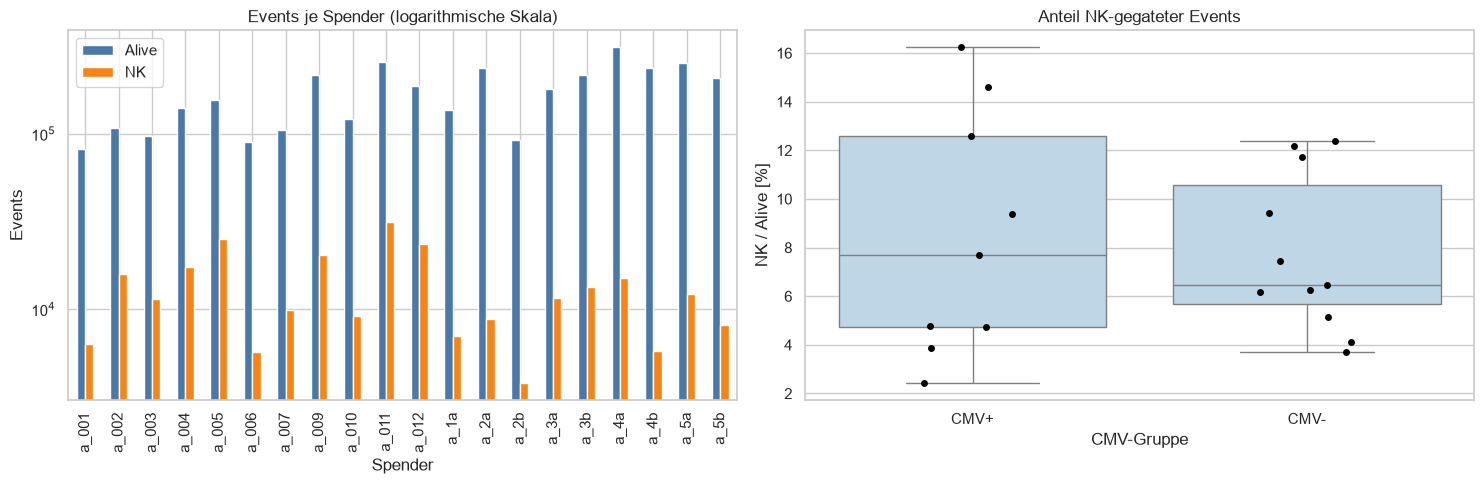

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

event_plot = sample_overview.set_index("sample")[["alive_events", "nk_events"]]
event_plot.plot.bar(ax=axes[0], logy=True, color=["#4c78a8", "#f58518"])
axes[0].set(title="Events je Spender (logarithmische Skala)", xlabel="Spender", ylabel="Events")
axes[0].legend(["Alive", "NK"])

sns.boxplot(data=sample_overview, x="clinical_group", y="nk_percent_of_alive", ax=axes[1], color="#b8d7ee")
sns.stripplot(data=sample_overview, x="clinical_group", y="nk_percent_of_alive", ax=axes[1], color="black", jitter=0.15)
axes[1].set(title="Anteil NK-gegateter Events", xlabel="CMV-Gruppe", ylabel="NK / Alive [%]")
plt.tight_layout()
plt.show()

## 4. Eine FCS-Datei mit FlowKit öffnen

Die Cytobank-Exporte melden das Ende des FCS-Datenblocks um genau ein Byte versetzt. FlowKit verweigert deshalb standardmäßig das Laden. `ignore_offset_error=True` ist hier ein bewusster, datensatzspezifischer Workaround. Eventzahl und erste Messwerte wurden zusätzlich mit dem unabhängigen Parser in `untersuchung/inspect_fcs.py` gegengeprüft.

In [7]:
example_path = NK_DIR / labels.loc[0, "fcs_filename"]

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=r"FCS file .* reported incorrect data offset.*")
    example_sample = fk.Sample(str(example_path), ignore_offset_error=True)

channel_table = pd.DataFrame({
    "channel_number": np.arange(1, len(example_sample.pnn_labels) + 1),
    "detector_name_pnn": example_sample.pnn_labels,
    "marker_name_pns": example_sample.pns_labels,
})
channel_table["analysis_marker"] = channel_table["marker_name_pns"].isin(markers)

print(f"Datei: {example_path.name}")
print(f"Events: {example_sample.event_count:,}")
print(f"Kanäle: {len(channel_table)}")
display(channel_table)

Datei: a_001_NK.fcs
Events: 6,320
Kanäle: 43


,channel_number,detector_name_pnn,marker_name_pns,analysis_marker
0,1,Time,Time,False
1,2,Cell_length,Cell_length,False
2,3,CD3(Cd112)Dd,CD3,True
3,4,Dead(In115)Dd,Dead,False
4,5,(La139)Dd,(La139)Dd,False
5,6,CD27(Pr141)Dd,CD27,True
6,7,CD19(Nd142)Dd,CD19,True
7,8,CD4(Nd143)Dd,CD4,True
8,9,CD8(Nd144)Dd,CD8,True
9,10,CD57(Nd145)Dd,CD57,True


In [8]:
example_raw = example_sample.as_dataframe(source="raw")

# FlowKit liefert einen MultiIndex aus Detektorname (PnN) und Markername (PnS).
# Für die biologische Analyse verwenden wir die eindeutigen PnS-Markernamen.
example_raw.columns = example_raw.columns.get_level_values("pns")
assert example_raw.columns.is_unique
assert set(markers).issubset(example_raw.columns)

example_markers = example_raw.loc[:, markers].copy()
display(example_markers.head())

# Quantile zeigen die sehr unterschiedlichen Rohwertskalen der Marker.
example_markers[["CD3", "CD56", "CD57", "NKG2C", "CD16", "CD94"]].quantile(
    [0, 0.01, 0.5, 0.99, 1.0]
).T

pns,CD3,CD27,CD19,CD4,CD8,CD57,2DL1-S1,TRAIL,2DL2-L3-S2,CD16,...,CD94,CD34,CCR7,2DL3,NKG2A,HLA-DR,2DL4,CD56,2DL5,CD25
0,10.474324,-0.623074,0.679764,2.048464,64.103661,1.574079,-0.358173,-0.051273,15.948585,239.341156,...,5.152357,-0.837307,1.288167,109.977394,-0.153611,-0.080781,1.514798,-0.579602,4.862881,-0.353626
1,48.966702,-0.831878,-0.621292,1.809320,-0.533633,-0.995035,-0.147270,-0.945684,-0.073548,5.937965,...,11.731606,-0.483870,-0.729481,-0.227698,-0.940522,0.956040,4.845481,14.093897,-0.442725,-0.158298
2,1.739581,-0.140540,-0.172185,-0.349869,-0.249664,-0.853839,-0.138628,-0.558301,4.312078,126.810234,...,1.154447,-0.156457,-0.957442,-0.347323,-0.396695,6.015396,2.239985,-0.134505,-0.647324,-0.169738
3,-0.751199,0.980779,-0.334391,9.639506,1.577843,348.869385,25.064701,-0.833648,17.031397,435.871460,...,1.457750,-0.272652,-0.934899,163.264603,4.150362,4.493876,0.333018,65.263695,-0.094598,-0.105058
4,-0.155269,10.146503,-0.581629,-0.129026,-0.482401,178.981598,0.653795,-0.574251,26.249693,418.548218,...,-0.306886,-0.992387,0.790790,125.527489,6.058481,20.482588,-0.633398,112.382095,-0.772371,-0.907734


,0.00,0.01,0.50,0.99,1.00
pns,,,,,
CD3,-0.999746,-0.976143,1.341413,67.750808,73.679474
CD56,-0.990289,-0.782732,42.070959,532.203875,990.982483
CD57,-0.999310,-0.979329,9.588985,603.022642,929.988342
NKG2C,-0.999857,-0.981074,-0.241653,93.657635,294.473053
CD16,-0.999504,-0.919433,175.143852,558.675409,1192.079102
CD94,-0.997765,-0.912640,33.313099,360.463150,720.097351


## 5. Balanciertes Subsampling aller NK-Samples

Für eine gemeinsame explorative Darstellung ziehen wir höchstens 1.000 Zellen je Spender. Damit erhält jeder Spender dasselbe Gewicht. Das Subsampling ist durch einen festen Seed reproduzierbar. Die vollständigen FCS-Dateien bleiben weiterhin unangetastet.

In [9]:
CELLS_PER_DONOR = 2_000
balanced_parts = []
full_parts = []

for row_number, row in labels.sort_values("sample_id").reset_index(drop=True).iterrows():
    path = NK_DIR / row["fcs_filename"]
    with warnings.catch_warnings():
        # Nur die bereits erklärte Ein-Byte-Offsetwarnung dieses Datensatzes ausblenden.
        warnings.filterwarnings("ignore", message=r"FCS file .* reported incorrect data offset.*")
        sample = fk.Sample(str(path), ignore_offset_error=True)

    frame = sample.as_dataframe(source="raw")
    frame.columns = frame.columns.get_level_values("pns")
    frame = frame.loc[:, markers].copy()

    # Vollständige Tabelle für nachgelagerte Analysen: keine Zellen verwerfen.
    full_frame = frame.copy()
    full_frame.insert(0, "clinical_group", row["clinical_group"])
    full_frame.insert(0, "label", row["label"])
    full_frame.insert(0, "sample_id", row["sample_id"])
    full_parts.append(full_frame)

    # Balancierter Explorationsdatensatz: höchstens gleich viele Zellen je Spender.
    n_take = min(CELLS_PER_DONOR, len(frame))
    frame = frame.sample(n=n_take, random_state=RANDOM_SEED + row_number).copy()
    frame.insert(0, "clinical_group", row["clinical_group"])
    frame.insert(0, "label", row["label"])
    frame.insert(0, "sample_id", row["sample_id"])
    balanced_parts.append(frame)

nk_full_raw = pd.concat(full_parts, ignore_index=True)
nk_balanced_raw = pd.concat(balanced_parts, ignore_index=True)

assert nk_full_raw.columns.tolist() == nk_balanced_raw.columns.tolist()
assert len(nk_full_raw) == sample_overview["nk_events"].sum()
assert nk_full_raw[markers].notna().all().all()
assert np.isfinite(nk_full_raw[markers].to_numpy()).all()
assert nk_balanced_raw[markers].notna().all().all()
assert np.isfinite(nk_balanced_raw[markers].to_numpy()).all()

display(nk_balanced_raw.groupby(["clinical_group", "sample_id"]).size().rename("sampled_cells").to_frame())
print(f"Vollständiger Datensatz: {len(nk_full_raw):,} Zellen × {len(markers)} Marker")
print(f"Balancierter Explorationsdatensatz: {len(nk_balanced_raw):,} Zellen × {len(markers)} Marker")

sampled_cells
clinical_group sample_id               
CMV+           a_001               2000
               a_002               2000
               a_005               2000
               a_007               2000
               a_012               2000
               a_4a                2000
               a_4b                2000
               a_5a                2000
               a_5b                2000
CMV−           a_003               2000
               a_004               2000
               a_006               2000
               a_009               2000
               a_010               2000
               a_011               2000
               a_1a                2000
               a_2a                2000
               a_2b                2000
               a_3a                2000
               a_3b                2000

Vollständiger Datensatz: 261,593 Zellen × 37 Marker
Balancierter Explorationsdatensatz: 40,000 Zellen × 37 Marker


## 6. Explorative ArcSinh-Transformation

CyTOF-Intensitäten sind stark rechtsschief. Für die ersten Plots verwenden wir deshalb `arcsinh(x / 5)`. Der Kofaktor 5 ist hier eine **explorative Entscheidung**, kein unveränderliches Naturgesetz. Für den finalen Benchmark müssen Transformation und Kofaktor begründet, für alle Methoden identisch angewandt und innerhalb der Cross-Validation ohne Datenleck behandelt werden.

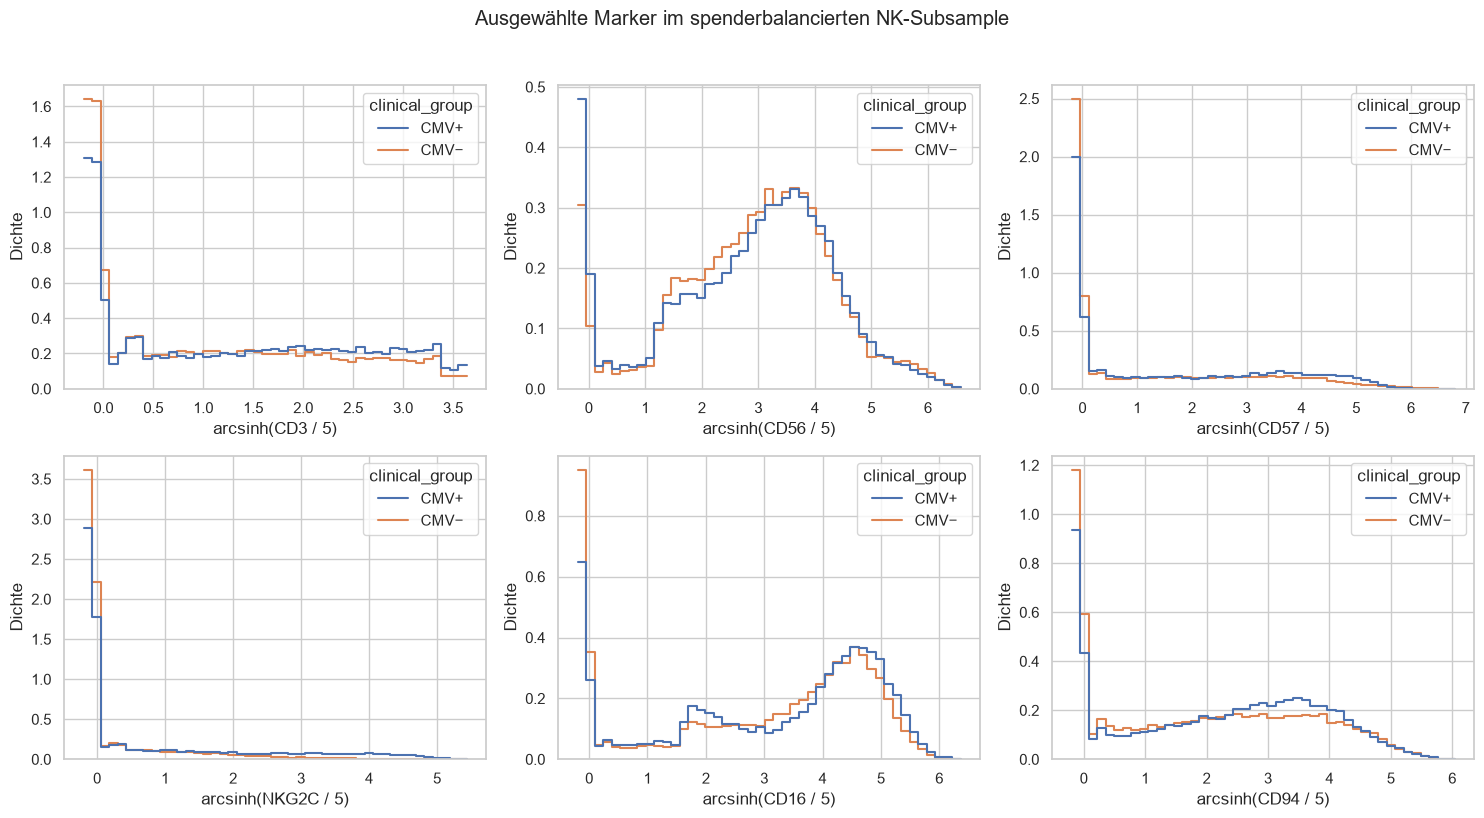

In [10]:
ARCSINH_COFACTOR = 5.0
nk_balanced = nk_balanced_raw[["sample_id", "label", "clinical_group"]].copy()
nk_balanced[markers] = np.arcsinh(nk_balanced_raw[markers] / ARCSINH_COFACTOR)

selected_markers = ["CD3", "CD56", "CD57", "NKG2C", "CD16", "CD94"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for marker, axis in zip(selected_markers, axes.flat):
    sns.histplot(
        data=nk_balanced, x=marker, hue="clinical_group", bins=45,
        stat="density", common_norm=False, element="step", fill=False, ax=axis,
    )
    axis.set(xlabel=f"arcsinh({marker} / {ARCSINH_COFACTOR:g})", ylabel="Dichte")

fig.suptitle("Ausgewählte Marker im spenderbalancierten NK-Subsample", y=1.02)
plt.tight_layout()
plt.show()

Die Publikation beschreibt eine seltene CMV+-assoziierte Population mit erhöhtem NKG2C und CD57. Der folgende Plot ist nur eine visuelle Plausibilitätsprüfung. Er definiert noch kein Gate und darf nicht als unabhängiger statistischer Nachweis interpretiert werden.

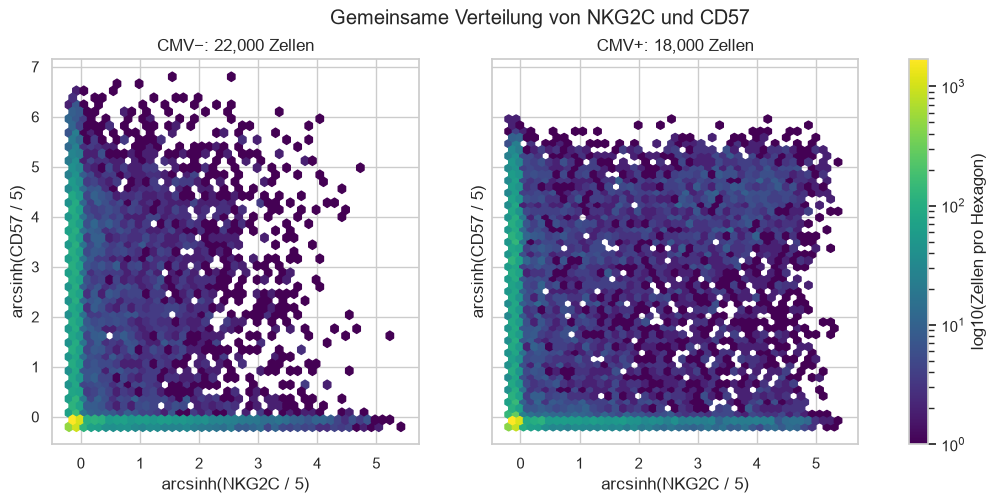

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for axis, group in zip(axes, ["CMV−", "CMV+"]):
    subset = nk_balanced.loc[nk_balanced["clinical_group"] == group]
    density = axis.hexbin(
        subset["NKG2C"], subset["CD57"], gridsize=45, mincnt=1, bins="log", cmap="viridis",
    )
    axis.set(
        title=f"{group}: {len(subset):,} Zellen",
        xlabel=f"arcsinh(NKG2C / {ARCSINH_COFACTOR:g})",
        ylabel=f"arcsinh(CD57 / {ARCSINH_COFACTOR:g})",
    )

fig.colorbar(density, ax=axes, label="log10(Zellen pro Hexagon)")
fig.suptitle("Gemeinsame Verteilung von NKG2C und CD57")
plt.show()

## 7. Preprocessing-Status für Aufgabe 4 und 5

**Kurzantwort:** Der Datensatz ist biologisch vorverarbeitet, aber nicht fertig numerisch vorverarbeitet. Die FCS-Dateien enthalten bereits Gates für lebende, von Doubletten bereinigte Zellen (`gated_alive`) sowie eine zusätzliche NK-Selektion (`gated_NK`). Auch Labels und die Auswahl der 37 Analysemarker sind vorgegeben. `source="raw"` liefert jedoch weiterhin untransformierte Intensitäten mit markerabhängig sehr verschiedenen Skalen und teilweise negativen Hintergrundwerten.

Die oben erzeugte Variable `nk_balanced` enthält zwar `arcsinh(x / 5)`, aber **noch keine z-Score-Standardisierung**. Sie ist ein explorativer Datensatz und darf nicht versehentlich als bereits fertig vorverarbeiteter Benchmark-Datensatz verstanden werden.

Für Aufgabe 4 und 5 empfehlen wir daher folgende feste Reihenfolge:

1. Spenderweise in Training und Test aufteilen; niemals Zellen eines Spenders auf beide Seiten verteilen.
2. Nur die 37 Marker verwenden und pro Spender gleich viele Zellen ziehen bzw. Spender gleich gewichten.
3. `arcsinh(x / 5)` auf Training und Test anwenden. Diese feste elementweise Transformation lernt keine Stichprobenstatistik. Der Kofaktor muss vor dem finalen Benchmark festgelegt oder ausschließlich in innerer CV gewählt werden.
4. Für distanz-, gradienten- und projektionsbasierte Verfahren anschließend markerweise z-standardisieren. Mittelwert und Standardabweichung **nur auf den Zellen der Trainingsspender des jeweiligen äußeren Folds** schätzen und unverändert auf Validierungs-/Testspender anwenden.
5. Aufgabe 5 muss exakt den Transformer und das Modell aus Aufgabe 4 wiederverwenden. Der Zellscore wird auf den identisch transformierten Zellen berechnet; es wird dafür kein neuer Scaler auf allen Daten gefittet.

Nicht empfehlenswert ist eine separate z-Standardisierung jedes einzelnen Spenders: Sie kann gerade die zwischen Spendern unterschiedlichen Expressionsniveaus entfernen, die das CMV-Signal tragen könnten. Auch ein einmaliger `StandardScaler.fit` auf allen 20 Spendern vor der Cross-Validation wäre Data Leakage. Für ein baumbasiertes Vergleichsmodell ist z-Scoring technisch meist nicht erforderlich; `arcsinh` und dieselben spenderweisen Splits sollten für einen nachvollziehbaren Vergleich trotzdem konsistent bleiben.

In [12]:
from sklearn.preprocessing import StandardScaler

def arcsinh_transform(frame, marker_names=markers, cofactor=ARCSINH_COFACTOR):
    """Feste CyTOF-Transformation; verändert das Eingabe-DataFrame nicht."""
    transformed = frame.copy()
    transformed.loc[:, marker_names] = np.arcsinh(
        transformed.loc[:, marker_names] / cofactor
    )
    return transformed

def fit_training_scaler(transformed_frame, train_sample_ids, marker_names=markers):
    """Fitte z-Scoring ausschließlich auf den Spendern eines Trainingsfolds."""
    train_mask = transformed_frame["sample_id"].isin(train_sample_ids)
    if not train_mask.any():
        raise ValueError("Keiner der angegebenen Trainingsspender wurde gefunden.")
    return StandardScaler().fit(transformed_frame.loc[train_mask, marker_names])

def apply_training_scaler(transformed_frame, scaler, marker_names=markers):
    """Wende einen bereits im Trainingsfold gefitteten Scaler an."""
    scaled = transformed_frame.copy()
    scaled.loc[:, marker_names] = scaler.transform(scaled.loc[:, marker_names])
    return scaled

# Verwendung später innerhalb jedes äußeren CV-Folds:
# fold_data = arcsinh_transform(nk_balanced_raw)
# scaler = fit_training_scaler(fold_data, train_sample_ids)
# train_scaled = apply_training_scaler(
#     fold_data[fold_data.sample_id.isin(train_sample_ids)], scaler
# )
# test_scaled = apply_training_scaler(
#     fold_data[fold_data.sample_id.isin(test_sample_ids)], scaler
# )

## 8. Zwischenfazit und nächste Schritte

Dieses Notebook prüft bereits automatisch:

- 20 passende Alive- und 20 passende NK-Dateien,
- 11 CMV−- und 9 CMV+-Spender,
- 37 eindeutige Analysemarker,
- konsistente Markerzuordnung in den geladenen FCS-Dateien,
- keine fehlenden oder unendlichen Werte im balancierten Subsample.

Als Nächstes sollten in `02_dimensionality_reduction.ipynb` mehrere klar definierte Vorverarbeitungsvarianten und spenderbalancierte Subsamples für PCA, t-SNE und UMAP verglichen werden. Parameter, Zufallsseeds und ein quantitatives Nachbarschaftsmaß müssen dabei explizit dokumentiert werden. Für Aufgabe 4 und 5 gilt die in Abschnitt 7 festgelegte, spenderweise und Cross-Validation-sichere Pipeline.

In [13]:
# --- Export artifacts for downstream notebooks ---
ARTIFACT_DIR = PROJECT_ROOT
ARTIFACT_DIR.mkdir(exist_ok=True)

# Untransformed, donor-balanced subsample (metadata + raw marker intensities)
nk_balanced_raw.to_parquet(ARTIFACT_DIR / "nk_balanced_raw.parquet", index=False)

nk_full_raw.to_parquet(ARTIFACT_DIR / "nk_full_raw.parquet", index=False)
# nk_full_raw = the full gated_NK table (all cells, all donors), pre-subsampling,
# with the same meta_cols + analysis_markers structure as nk_balanced_raw.

# Channel/marker metadata, so notebook 02 never needs FlowKit again
channel_table.to_parquet(ARTIFACT_DIR / "channel_table.parquet", index=False)
labels.to_csv(ARTIFACT_DIR / "labels.csv", index=False)

print(f"Exported {len(nk_balanced_raw):,} cells × {len(markers)} markers to {ARTIFACT_DIR}")

Exported 40,000 cells × 37 markers to C:\Users\marie\Documents\System Teamproject\SSBI-Project
